In [1]:
SINGAN_AUGMENTED_DATASETS_PATH = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets'
DIFFUSION_AUGMENTED_DATASETS_PATH = '/home/miguel/GI/1.5 - Synthetic Data Generation/diffuse-gen/diffuse-gen/augmented_dataset'
dataset_path = DIFFUSION_AUGMENTED_DATASETS_PATH

In [6]:
# import os
# import glob

In [5]:
# for folder in os.listdir(dataset_path):
#     expansion_factor = folder.split('_')[-1]
#     expansion_factor = float(expansion_factor)
#     for cv_subject in os.listdir(os.path.join(dataset_path, folder)):
#         train_folder_path = os.path.join(dataset_path, folder, cv_subject, 'train')
#         val_folder_path = os.path.join(dataset_path, folder, cv_subject, 'val')

In [8]:
# segmentation_path = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_0.5/FD-027/train'

In [9]:
# image_paths = [file for file in sorted(glob.glob(os.path.join(segmentation_path, '*image*.png'))) if 'mask' not in file]
# mask_paths = sorted(glob.glob(os.path.join(segmentation_path, '*mask.png'))) 

In [39]:
len(image_paths)

11254

In [40]:
len(mask_paths)

11254

In [ ]:
for file in os.listdir(segmentation_path):
    

    id = file.split('_')[0]


FD-031-slice-14-image-synthetic-27
FD-029-slice-12-image-synthetic-51
FD-029-slice-21-image-synthetic-3
FD-032-slice-19-image-synthetic-62
FD-031-slice-61-image-synthetic-16
FD-029-slice-14-image-synthetic-1
FD-031-slice-24-image-synthetic-76
FD-030-slice-72-image-synthetic-35
FD-032-slice-01-image-synthetic-42
FD-030-slice-13-image-synthetic-57
FD-030-slice-09-image-synthetic-27
FD-030-slice-68-image-synthetic-66
FD-029-slice-03-image-synthetic-41
FD-030-slice-13-image-synthetic-49
FD-031-slice-61-image-synthetic-6
FD-029-slice-03-image-synthetic-44
FD-029-slice-28-image-synthetic-53
FD-030-slice-27-image-synthetic-19
FD-031-slice-71-image-synthetic-17
FD-029-slice-06-image-synthetic-8
FD-032-slice-04-image.png
FD-031-slice-72-image-synthetic-8
FD-030-slice-29-image-synthetic-46
FD-031-slice-07-image-synthetic-16
FD-030-slice-03-image-synthetic-44
FD-032-slice-05-image-synthetic-53
FD-031-slice-10-image-synthetic-62
FD-031-slice-68-image-synthetic-69
FD-030-slice-21-image-synthetic-43

In [33]:
file.split('_')[0]

'FD-031-slice-14-image-synthetic-27'

In [ ]:
os.cur

In [42]:
train_dir = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_1.0/FD-027/train'

In [46]:
train_dataset = MadisonDatasetLabeled(train_dir, augment=True)

NameError: name 'MadisonDatasetLabeled' is not defined

In [15]:
import os
import pandas as pd

In [16]:
subjects = [
    'FD-027', 'FD-029', 'FD-030', 'FD-031', 'FD-032'
]
# SINGAN_AUGMENTED_DATASETS_PATH = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets'

In [19]:
dice_coefficients = []
folder = 'augmented_dataset_expansion_factor_16.0_hq_samples'
for cv_subject in subjects:
    path = f'unet_performance_statistics_diffusion_16_{cv_subject}.csv'
    data = pd.read_csv(path)
    cv_dice = data['best_dice_coefficient'].values[-1]
    train_folder_path = os.path.join(dataset_path, cv_subject, 'train')

    train_files = [file for file in os.listdir(train_folder_path) if 'mask' not in file]
    train_files_synthetic = [file for file in train_files if 'synthetic' in file]
    train_files_real = [file for file in train_files if 'synthetic' not in file]

    num_train_samples = len(os.listdir(train_folder_path))
    dice_coefficients.append({
        'cv_subject': cv_subject,
        'cv_dice_coefficient': cv_dice,
        'num_train_samples': len(train_files),
        'num_train_samples_synthetic': len(train_files_synthetic),
        'num_train_samples_real': len(train_files_real),
    })

In [ ]:
# dice_coefficients = []
# folder = 'augmented_dataset_expansion_factor_16.0_hq_samples'
# for cv_subject in subjects:
#     path = f'unet_performance_statistics_16_{cv_subject}.csv'
#     data = pd.read_csv(path)
#     cv_dice = data['best_dice_coefficient'].values[-1]
#     train_folder_path = os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder, cv_subject, 'train')

#     train_files = [file for file in os.listdir(train_folder_path) if 'mask' not in file]
#     train_files_synthetic = [file for file in train_files if 'synthetic' in file]
#     train_files_real = [file for file in train_files if 'synthetic' not in file]

#     num_train_samples = len(os.listdir(train_folder_path))
#     dice_coefficients.append({
#         'cv_subject': cv_subject,
#         'cv_dice_coefficient': cv_dice,
#         'num_train_samples': len(train_files),
#         'num_train_samples_synthetic': len(train_files_synthetic),
#         'num_train_samples_real': len(train_files_real),
#     })

In [20]:
dice_coefficients_df = pd.DataFrame(dice_coefficients)

In [21]:
dice_coefficients_df['expansion_factor'] = dice_coefficients_df['num_train_samples'] / dice_coefficients_df['num_train_samples_real']

In [22]:
dice_coefficients_df

,cv_subject,cv_dice_coefficient,num_train_samples,num_train_samples_synthetic,num_train_samples_real,expansion_factor
0,FD-027,0.748664,703,415,288,2.440972
1,FD-029,0.759477,705,417,288,2.447917
2,FD-030,0.807982,709,421,288,2.461806
3,FD-031,0.803531,700,412,288,2.430556
4,FD-032,0.548250,703,415,288,2.440972


In [23]:
old_dice_scores = {
    'FD-032': 0.5708,
    'FD-030': 0.8089,
    'FD-027': 0.7421,
    'FD-029': 0.7556,
    'FD-031': 0.8529
}

In [24]:
dice_coefficients_df['dice_score_no_augmentation'] = dice_coefficients_df['cv_subject'].map(old_dice_scores)

In [25]:
dice_coefficients_df['score_change'] = dice_coefficients_df['cv_dice_coefficient'] - dice_coefficients_df['dice_score_no_augmentation']

In [26]:
dice_coefficients_df['dice_score_no_augmentation'].mean()

np.float64(0.74606)

In [27]:
dice_coefficients_df[['cv_subject', 'cv_dice_coefficient', 'dice_score_no_augmentation', 'cv_dice_coefficient']]

,cv_subject,cv_dice_coefficient,dice_score_no_augmentation,cv_dice_coefficient
0,FD-027,0.748664,0.7421,0.748664
1,FD-029,0.759477,0.7556,0.759477
2,FD-030,0.807982,0.8089,0.807982
3,FD-031,0.803531,0.8529,0.803531
4,FD-032,0.548250,0.5708,0.548250


In [28]:
import matplotlib.pyplot as plt

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_dice_by_subject(df):
    subjects = df['cv_subject']
    no_aug   = df['dice_score_no_augmentation']
    with_aug = df['cv_dice_coefficient']

    x = np.arange(len(subjects))
    width = 0.35

    plt.figure(figsize=(12, 6))          # ← increase width & height here
    plt.bar(x - width/2, no_aug,  width, label='No Augmentation')
    plt.bar(x + width/2, with_aug, width, label='With Augmentation')
    plt.xticks(x, subjects, rotation=45, ha='right')
    plt.xlabel('Subject')
    plt.ylabel('Dice Score')
    plt.title('Dice Score by Subject: No Augmentation vs With Augmentation')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [30]:

df = dice_coefficients_df  


In [33]:
dice_coefficients_df

,cv_subject,cv_dice_coefficient,num_train_samples,num_train_samples_synthetic,num_train_samples_real,expansion_factor,dice_score_no_augmentation,score_change
0,FD-027,0.748664,703,415,288,2.440972,0.7421,0.006564
1,FD-029,0.759477,705,417,288,2.447917,0.7556,0.003877
2,FD-030,0.807982,709,421,288,2.461806,0.8089,-0.000918
3,FD-031,0.803531,700,412,288,2.430556,0.8529,-0.049369
4,FD-032,0.548250,703,415,288,2.440972,0.5708,-0.022550


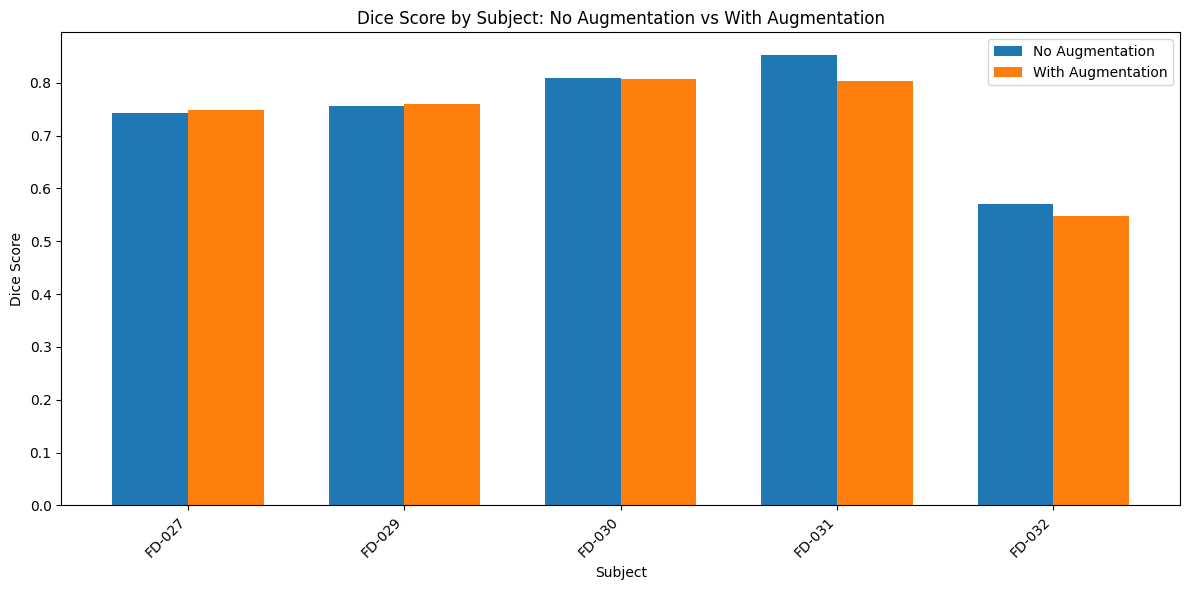

In [ ]:
plot_dice_by_subject(dice_coefficients_df)z